# Kagome lattics dynamics with Majorana Propagation under Fermi-Hubbard model

The following is the analogue of what was done in 'chainmajorana.ipynb' with the difference that we are now considering a 2D Kagome lattice with periodic boundary conditions.

In [ ]:
try:
    from spd.SparsePauliDynamics import *
    from spd.BaseOperatorRepresentation import * 
except ImportError:
    print("\n" + "="*60)
    print("REQUIRED PACKAGE 'spd' NOT FOUND")
    print("="*60)
    print("This notebook relies on the 'spd' package.")
    print("Please install it before proceeding:\n")
    print("   pip install git+https://github.com/tbegusic/spd.git")
    print("="*60 + "\n")
    raise

import numpy as np
import matplotlib.pyplot as plt
from qiskit_nature.second_q.hamiltonians.lattices import (
    KagomeLattice,
    BoundaryCondition,
)
from qiskit_nature.second_q.operators import FermionicOp
from qiskit.quantum_info import SparsePauliOp

In [ ]:
# possible changes: change t, change U, change dt, change step, change threshold, change S, change boundary conditions, change observable

Lx, Ly = 3, 2
kagome = KagomeLattice(rows=Lx, cols=Ly,
    boundary_condition=(BoundaryCondition.PERIODIC, BoundaryCondition.PERIODIC)
)
nq = kagome.num_nodes
nmodes = 2*nq
weighted_edges = kagome.weighted_edge_list
nlist = [(i, j) for i, j, _ in weighted_edges if i != j]

In [ ]:
t = 1
U = 1
dt = 0.12
step = 6
nsteps = int(step/dt)

threshold = 2**-8

In [ ]:
nmodes = 2*nq
ham_hop = FermionicOp({},nmodes)
ham_rep = FermionicOp({},nmodes)


for i, j in nlist:
    spinup_i = 2*i
    spinup_j = 2*j
    ham_hop += FermionicOp({f'+_{spinup_i} -_{spinup_j}': -t}, num_spin_orbitals=nmodes)
    ham_hop += FermionicOp({f'+_{spinup_j} -_{spinup_i}': -t}, num_spin_orbitals=nmodes)  

    spindown_i = 2*i + 1
    spindown_j = 2*j + 1
    ham_hop += FermionicOp({f'+_{spindown_i} -_{spindown_j}': -t}, num_spin_orbitals=nmodes)
    ham_hop += FermionicOp({f'+_{spindown_j} -_{spindown_i}': -t}, num_spin_orbitals=nmodes)

for q in range(nq):
    up_idx = 2*q
    down_idx = 2*q + 1
    n_up = FermionicOp({f'+_{up_idx} -_{up_idx}': 1}, num_spin_orbitals=nmodes)
    n_down = FermionicOp({f'+_{down_idx} -_{down_idx}': 1}, num_spin_orbitals=nmodes)
    ham_rep += U * n_up @ n_down

In [ ]:
central = (nq - 1)//2
obs_central_idx = 2 * central
obs_ferm = FermionicOp({f'+_{obs_central_idx} -_{obs_central_idx}': 1}, num_spin_orbitals=nmodes)

In [ ]:
obs_majorana = MajoranaRepresentation.from_fermionic_op(obs_ferm)

h_hop_majorana = MajoranaRepresentation.fermionic_to_sparse_pauli_op(ham_hop)
h_rep_majorana = MajoranaRepresentation.fermionic_to_sparse_pauli_op(ham_rep)  

op = (dt * h_hop_majorana) + (dt * h_rep_majorana)

state = np.zeros(nmodes, dtype=int)
for q in range(nq):
    if q % 2 == 0:
        state[2*q+1] = 1
    else:
        state[2*q] = 1

In [ ]:
S = 6
def process(obs_rep):
    """Compute expectation value and apply S truncation."""
    exp_val = MajoranaRepresentation.exp_val_comp_basis_state(obs_rep, state)

    # Discard strings with more than S unpaired Majoranas
    trunc = obs_rep.nonp_count <= S
    obs_rep.bits = obs_rep.bits[trunc]
    obs_rep.coeffs = obs_rep.coeffs[trunc]

    return exp_val

sim = Simulation(obs_majorana.copy(), op, threshold=threshold)
r = sim.run_dynamics(nsteps, process=process, process_every=1)

results = np.array(r)

In [ ]:
plt.plot(np.arange(len(results))*dt, results)
plt.show()

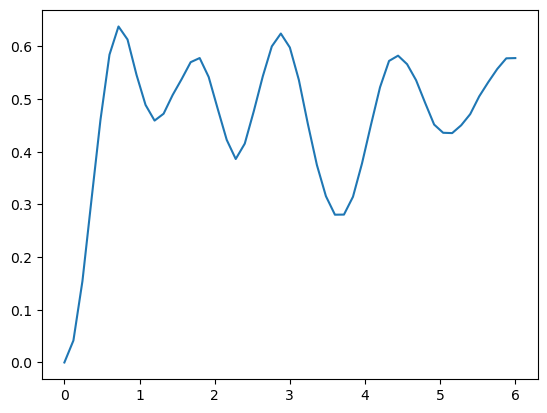